In [ ]:
# import pandas as pd
# from rouge_score import rouge_scorer
# from bert_score import score as bertscore
# import numpy as np
# from scipy import stats


# ft = pd.read_csv("finetuned_clean_judged.csv", sep=",", engine="python", on_bad_lines='warn')
# zs = pd.read_csv("zeroshot_clean_judged.csv", sep=",", engine="python", on_bad_lines='warn')

# print(ft.shape)
# print(ft.columns.tolist())
# print(ft.head(2))

# ft["model"] = "finetuned"
# zs["model"] = "zeroshot"

# # Shape check
# print(ft.shape, zs.shape)

# # Column check
# expected_cols = ['example_id','issue','topic','stance','input_article',
#                  'generated_summary','roundup_text','neutrality','coverage',
#                  'faithfulness','roundup_alignment','reasoning']
# print("Missing cols ft:", set(expected_cols) - set(ft.columns))
# print("Missing cols zs:", set(expected_cols) - set(zs.columns))

# # Null check on critical columns
# for col in ['generated_summary', 'roundup_text', 'neutrality']:
#     print(f"{col} nulls — ft: {ft[col].isnull().sum()}, zs: {zs[col].isnull().sum()}")

# # Stance distribution
# print(ft['stance'].value_counts())
# print(zs['stance'].value_counts())


# df = pd.concat([ft, zs], ignore_index=True)

# # --- ROUGE ---
# scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

# def compute_rouge(row):
#     scores = scorer.score(row["roundup_text"], row["generated_summary"])
#     return pd.Series({
#         "rouge1_f": scores["rouge1"].fmeasure,
#         "rouge2_f": scores["rouge2"].fmeasure,
#         "rougeL_f": scores["rougeL"].fmeasure,
#     })

# rouge_df = df.apply(compute_rouge, axis=1)
# df = pd.concat([df, rouge_df], axis=1)

# # --- BERTScore (batched, slow — do once, cache) ---
# P, R, F1 = bertscore(
#     df["generated_summary"].tolist(),
#     df["roundup_text"].tolist(),
#     lang="en",
#     rescale_with_baseline=True,
#     verbose=True
# )
# df["bertscore_f1"] = F1.numpy()

# df.to_csv("full_evaluated.csv", index=False, sep="\t")
# print(df.groupby(["model", "stance"])[["rouge1_f","rouge2_f","rougeL_f","bertscore_f1"]].mean().round(4))

(921, 12)
['example_id', 'issue', 'topic', 'stance', 'input_article', 'generated_summary', 'roundup_text', 'neutrality', 'coverage', 'faithfulness', 'roundup_alignment', 'reasoning']
   example_id                                     issue           topic  \
0           0  'Howdy Modi' Event Draws President Trump  Foreign Policy   
1           0  'Howdy Modi' Event Draws President Trump  Foreign Policy   

   stance                                      input_article  \
0    left  HOUSTON — The foreign strategy of soothing ten...   
1  center  U.S. President Donald Trump and Indian Prime M...   

                                   generated_summary  \
0  Indian Prime Minister Narendra Modi met with P...   
1  President Donald Trump and Indian Prime Minist...   

                                        roundup_text  neutrality  coverage  \
0  President Donald Trump made an appearance at a...           4         3   
1  President Donald Trump made an appearance at a...           4         

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 4702.70it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


100%|██████████| 34/34 [07:42<00:00, 13.61s/it]


computing greedy matching.


100%|██████████| 29/29 [00:00<00:00, 39.14it/s]


done in 463.54 seconds, 3.97 sentences/sec
                  rouge1_f  rouge2_f  rougeL_f  bertscore_f1
model     stance                                            
finetuned center    0.3103    0.1192    0.2044        0.2384
          left      0.2936    0.1019    0.1920        0.1994
          right     0.3062    0.1085    0.1981        0.2170
zeroshot  center    0.3681    0.1357    0.2397        0.3266
          left      0.3419    0.1098    0.2177        0.2848
          right     0.3536    0.1199    0.2260        0.2988


In [25]:
import os
from rouge_score import rouge_scorer
from bert_score import score as bertscore
import pandas as pd
import numpy as np
from scipy import stats

# ── Encoding fix for latin-1/utf-8 mismatch in source files ──────────────────
def fix_encoding(text):
    if not isinstance(text, str):
        return text
    try:
        return text.encode('latin-1').decode('utf-8')
    except (UnicodeDecodeError, UnicodeEncodeError):
        return text

# ── Custom CSV loader that handles messy text fields ─────────────────────────
import csv

def load_messy_csv(filepath):
    rows = []
    with open(filepath, encoding="utf-8", newline='') as f:
        reader = csv.reader(f, quotechar='"', skipinitialspace=True)
        headers = next(reader)
        for row in reader:
            if len(row) == len(headers):
                rows.append(row)
            elif len(row) > len(headers):
                fixed = row[:len(headers)-1] + [','.join(row[len(headers)-1:])]
                rows.append(fixed)
    return pd.DataFrame(rows, columns=headers)

# ── Load judged files ─────────────────────────────────────────────────────────
CACHE_PATH      = "full_evaluated.csv"
CLEAN_PATH      = "full_evaluated_clean.csv"
CACHE_SAFE_PATH = "full_evaluated_safe.csv"  # tab-sep but only safe columns

# If clean CSV already exists, load it directly — skip all recomputation
if os.path.exists(CLEAN_PATH):
    print(f"Loading clean cache from {CLEAN_PATH}...")
    df = pd.read_csv(CLEAN_PATH)
    print(f"Loaded: {df.shape}")

elif os.path.exists(CACHE_PATH):
    # Try to load the existing (possibly messy) full_evaluated.csv
    print(f"Loading existing cache from {CACHE_PATH}...")
    try:
        df = pd.read_csv(CACHE_PATH, sep="\t", engine="python", on_bad_lines='warn')
        print(f"Loaded from cache: {df.shape}")
    except Exception as e:
        print(f"Cache load failed ({e}), rebuilding from source files...")
        df = None

    if df is None or df.shape[0] < 1800:
        print("Cache incomplete or failed — rebuilding...")
        os.remove(CACHE_PATH)

else:
    print("No cache found — computing ROUGE and BERTScore from scratch...")

    ft = load_messy_csv("finetuned_clean_judged.csv")
    zs = load_messy_csv("zeroshot_clean_judged.csv")
    ft["model"] = "finetuned"
    zs["model"] = "zeroshot"

    print(f"FT shape: {ft.shape}, ZS shape: {zs.shape}")

    df = pd.concat([ft, zs], ignore_index=True)

    # Fix encoding in text columns
    for col in ['input_article', 'generated_summary', 'roundup_text']:
        if col in df.columns:
            df[col] = df[col].apply(fix_encoding)

    # ── ROUGE ─────────────────────────────────────────────────────────────────
    print("Computing ROUGE...")
    _scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

    def compute_rouge(row):
        s = _scorer.score(str(row["roundup_text"]), str(row["generated_summary"]))
        return pd.Series({
            "rouge1_f": s["rouge1"].fmeasure,
            "rouge2_f": s["rouge2"].fmeasure,
            "rougeL_f": s["rougeL"].fmeasure,
        })

    rouge_df = df.apply(compute_rouge, axis=1)
    df = pd.concat([df, rouge_df], axis=1)
    print("ROUGE done.")

    # ── BERTScore ─────────────────────────────────────────────────────────────
    print("Computing BERTScore (this takes ~10 min)...")
    P, R, F1 = bertscore(
        df["generated_summary"].tolist(),
        df["roundup_text"].tolist(),
        lang="en",
        rescale_with_baseline=True,
        verbose=True
    )
    df["bertscore_f1"] = F1.numpy()
    print("BERTScore done.")

# ── Ensure numeric types ──────────────────────────────────────────────────────
for col in ["neutrality", "coverage", "faithfulness", "roundup_alignment",
            "rouge1_f", "rouge2_f", "rougeL_f", "bertscore_f1"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ── VAD (if not already computed) ────────────────────────────────────────────
if "valence" not in df.columns:
    print("VAD columns not found — run the VAD cell before saving clean CSV.")
else:
    for col in ["valence", "arousal", "dominance", "vad_coverage"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

# ── Save full_evaluated_clean.csv — safe columns only, no raw text ────────────
SAFE_COLS = [
    "example_id", "topic", "issue", "stance", "model",
    "neutrality", "coverage", "faithfulness", "roundup_alignment",
    "rouge1_f", "rouge2_f", "rougeL_f", "bertscore_f1",
    "valence", "arousal", "dominance", "vad_coverage",
    "reasoning"
]
save_cols = [c for c in SAFE_COLS if c in df.columns]
df[save_cols].to_csv(CLEAN_PATH, index=False)
print(f"Saved clean CSV: {CLEAN_PATH}")

# ── Verify ────────────────────────────────────────────────────────────────────
check = pd.read_csv(CLEAN_PATH)
print(f"\nClean CSV shape: {check.shape}")  # expect (1842, ~17)
print(f"Columns: {check.columns.tolist()}")
print(f"\nNaN check:")
print(check[["neutrality", "faithfulness", "rouge1_f", "bertscore_f1"]].isnull().sum())
print(f"\nModels: {check['model'].value_counts().to_dict()}")
print(f"Stances: {check['stance'].value_counts().to_dict()}")
print(f"\nQuick means:")
print(check.groupby("model")[["neutrality","faithfulness","rouge1_f","bertscore_f1"]].mean().round(4))

Loading clean cache from full_evaluated_clean.csv...
Loaded: (1842, 14)
VAD columns not found — run the VAD cell before saving clean CSV.
Saved clean CSV: full_evaluated_clean.csv

Clean CSV shape: (1842, 14)
Columns: ['example_id', 'topic', 'issue', 'stance', 'model', 'neutrality', 'coverage', 'faithfulness', 'roundup_alignment', 'rouge1_f', 'rouge2_f', 'rougeL_f', 'bertscore_f1', 'reasoning']

NaN check:
neutrality      0
faithfulness    0
rouge1_f        0
bertscore_f1    0
dtype: int64

Models: {'finetuned': 921, 'zeroshot': 921}
Stances: {'left': 614, 'center': 614, 'right': 614}

Quick means:
           neutrality  faithfulness  rouge1_f  bertscore_f1
model                                                      
finetuned      4.0087        2.5972    0.3033        0.2182
zeroshot       3.3692        4.1444    0.3545        0.3034


In [29]:
import re
from sentibank import archive

# ── Load warriner lexicon ─────────────────────────────────────────────────────
load = archive.load()
warriner_raw = load.origin("NoVAD_v2013")
warriner = warriner_raw.set_index("Word")[["V.Mean.Sum", "A.Mean.Sum", "D.Mean.Sum"]]
warriner.columns = ["valence", "arousal", "dominance"]
WARRINER_NEUTRAL = 5.0

def compute_vad_warriner(text: str) -> dict:
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {"valence": WARRINER_NEUTRAL, "arousal": WARRINER_NEUTRAL,
                "dominance": WARRINER_NEUTRAL, "n_matched": 0, "n_tokens": 0, "coverage": 0.0}
    tokens = re.findall(r"[a-z]+", text.lower())
    v_scores, a_scores, d_scores = [], [], []
    for word in tokens:
        if word in warriner.index:
            v_scores.append(warriner.loc[word, "valence"])
            a_scores.append(warriner.loc[word, "arousal"])
            d_scores.append(warriner.loc[word, "dominance"])
    n_matched = len(v_scores)
    n_tokens  = len(tokens)
    return {
        "valence":   sum(v_scores) / n_matched if n_matched > 0 else WARRINER_NEUTRAL,
        "arousal":   sum(a_scores) / n_matched if n_matched > 0 else WARRINER_NEUTRAL,
        "dominance": sum(d_scores) / n_matched if n_matched > 0 else WARRINER_NEUTRAL,
        "n_matched": n_matched,
        "n_tokens":  n_tokens,
        "coverage":  n_matched / n_tokens if n_tokens > 0 else 0.0
    }

# ── Get generated_summary text ────────────────────────────────────────────────
# df (from Block 0) may not have text columns if loaded from clean CSV
# Load summaries from source files if needed

if "generated_summary" not in df.columns:
    print("generated_summary not in df — loading from source judged files...")

    ft_raw = load_messy_csv("finetuned_clean_judged.csv")
    zs_raw = load_messy_csv("zeroshot_clean_judged.csv")
    ft_raw["model"] = "finetuned"
    zs_raw["model"] = "zeroshot"
    text_df = pd.concat([ft_raw, zs_raw], ignore_index=True)

    # Normalize example_id and stance for merging
    text_df["example_id"] = pd.to_numeric(text_df["example_id"], errors="coerce")
    df["example_id"]      = pd.to_numeric(df["example_id"], errors="coerce")

    # Keep only the key + text columns needed
    text_df = text_df[["example_id", "stance", "model", "generated_summary"]].copy()

    df = df.merge(text_df, on=["example_id", "stance", "model"], how="left")
    print(f"Merged generated_summary — null count: {df['generated_summary'].isnull().sum()}")
else:
    print("generated_summary already in df.")

# ── Apply VAD ─────────────────────────────────────────────────────────────────
print("Computing VAD...")
vad_results = df["generated_summary"].apply(compute_vad_warriner)
df["valence"]       = vad_results.apply(lambda x: x["valence"])
df["arousal"]       = vad_results.apply(lambda x: x["arousal"])
df["dominance"]     = vad_results.apply(lambda x: x["dominance"])
df["vad_coverage"]  = vad_results.apply(lambda x: x["coverage"])
df["vad_n_matched"] = vad_results.apply(lambda x: x["n_matched"])
print("VAD done.")

# ── Sanity check ──────────────────────────────────────────────────────────────
print(df.groupby(["model", "stance"])[
    ["valence","arousal","dominance","vad_coverage"]].mean().round(4))
print(f"\nRows with zero VAD coverage: {(df['vad_coverage'] == 0).sum()}")

# ── Resave clean CSV with VAD now included ────────────────────────────────────
SAFE_COLS = [
    "example_id", "topic", "issue", "stance", "model",
    "neutrality", "coverage", "faithfulness", "roundup_alignment",
    "rouge1_f", "rouge2_f", "rougeL_f", "bertscore_f1",
    "valence", "arousal", "dominance", "vad_coverage",
    "reasoning"
]
save_cols = [c for c in SAFE_COLS if c in df.columns]
df[save_cols].to_csv("full_evaluated_clean.csv", index=False)
print(f"Resaved full_evaluated_clean.csv with VAD: shape={df[save_cols].shape}")

generated_summary not in df — loading from source judged files...
Merged generated_summary — null count: 0
Computing VAD...
VAD done.
                  valence  arousal  dominance  vad_coverage
model     stance                                           
finetuned center   5.2882   4.0588     5.4058        0.3055
          left     5.2831   4.0581     5.4103        0.3082
          right    5.3044   4.0663     5.4258        0.3097
zeroshot  center   5.2805   4.1115     5.4074        0.3257
          left     5.2835   4.1047     5.3982        0.3216
          right    5.3280   4.0961     5.4210        0.3247

Rows with zero VAD coverage: 0
Resaved full_evaluated_clean.csv with VAD: shape=(1842, 18)


In [30]:
from scipy import stats

# VAD spread: per story per model, how much does valence vary across L/C/R?
vad_spread = (
    df.groupby(["model", "example_id"])["valence"]
    .agg(lambda x: x.max() - x.min())
    .reset_index()
    .rename(columns={"valence": "valence_spread"})
)

print(vad_spread.groupby("model")["valence_spread"].describe().round(4))

# Significance test
ft_spread = vad_spread[vad_spread["model"] == "finetuned"]["valence_spread"]
zs_spread = vad_spread[vad_spread["model"] == "zeroshot"]["valence_spread"]

t, p = stats.ttest_ind(ft_spread, zs_spread)
cohen_d = (ft_spread.mean() - zs_spread.mean()) / np.sqrt(
    (ft_spread.std()**2 + zs_spread.std()**2) / 2
)
print(f"\nVAD spread — finetuned mean: {ft_spread.mean():.4f}, zeroshot mean: {zs_spread.mean():.4f}")
print(f"t={t:.3f}, p={p:.4f}, Cohen's d={cohen_d:.4f}")

           count    mean     std     min     25%     50%     75%     max
model                                                                   
finetuned  307.0  0.3794  0.2686  0.0167  0.2003  0.3244  0.4833  1.9048
zeroshot   307.0  0.3924  0.2241  0.0147  0.2282  0.3553  0.5393  1.1786

VAD spread — finetuned mean: 0.3794, zeroshot mean: 0.3924
t=-0.654, p=0.5135, Cohen's d=-0.0528


In [31]:
judge_cols = ["neutrality", "faithfulness", "roundup_alignment"]

print(df.groupby(["model", "stance"])[judge_cols].mean().round(4))
print(df.groupby("model")[judge_cols].mean().round(4))

from scipy import stats

for col in judge_cols:
    ft_scores = df[df["model"]=="finetuned"].sort_values(["example_id","stance"])[col].astype(float)
    zs_scores = df[df["model"]=="zeroshot"].sort_values(["example_id","stance"])[col].astype(float)
    t, p = stats.ttest_rel(ft_scores, zs_scores)
    # Pooled SD for Cohen's d — not just ft std
    d = (ft_scores.mean() - zs_scores.mean()) / np.sqrt(
        (ft_scores.std()**2 + zs_scores.std()**2) / 2
    )
    print(f"{col}: t={t:.3f}, p={p:.4f}, Cohen's d={d:.4f}, "
          f"ft_mean={ft_scores.mean():.3f}, zs_mean={zs_scores.mean():.3f}")

                  neutrality  faithfulness  roundup_alignment
model     stance                                             
finetuned center      4.0554        2.6938             2.5081
          left        3.9283        2.5375             2.2801
          right       4.0423        2.5603             2.3876
zeroshot  center      3.4300        4.2020             3.2508
          left        3.3616        4.1075             3.0651
          right       3.3160        4.1238             3.0879
           neutrality  faithfulness  roundup_alignment
model                                                 
finetuned      4.0087        2.5972             2.3920
zeroshot       3.3692        4.1444             3.1346
neutrality: t=20.212, p=0.0000, Cohen's d=0.8095, ft_mean=4.009, zs_mean=3.369
faithfulness: t=-46.106, p=0.0000, Cohen's d=-1.9392, ft_mean=2.597, zs_mean=4.144
roundup_alignment: t=-26.814, p=0.0000, Cohen's d=-0.9391, ft_mean=2.392, zs_mean=3.135


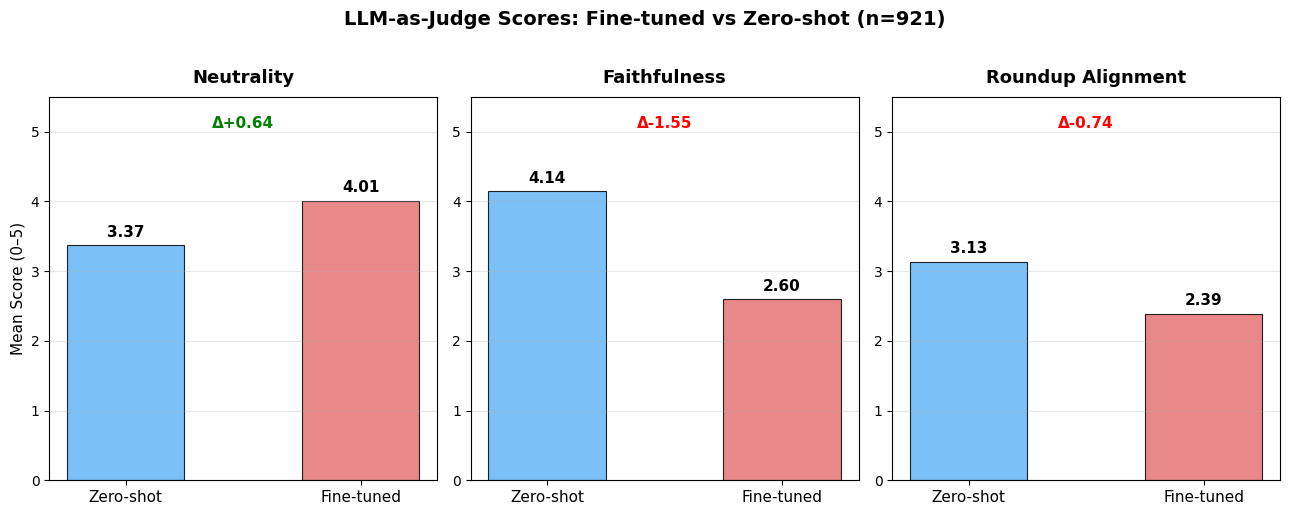

Saved: fig1_aggregate_judge_scores.png


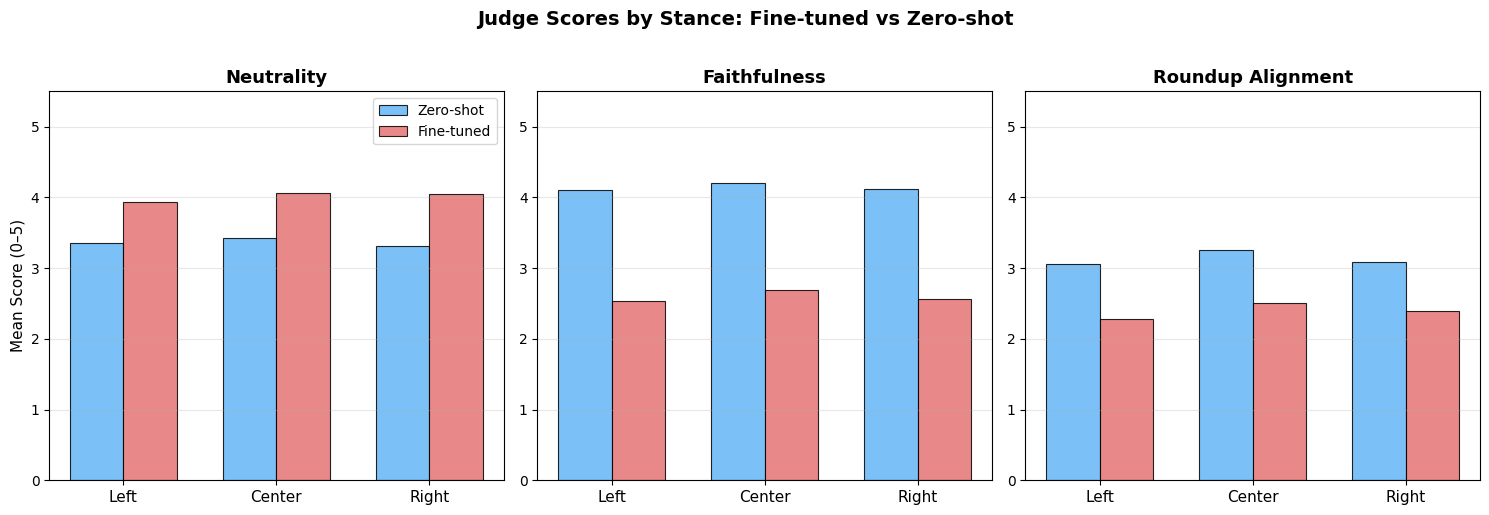

Saved: fig2_stance_judge_scores.png


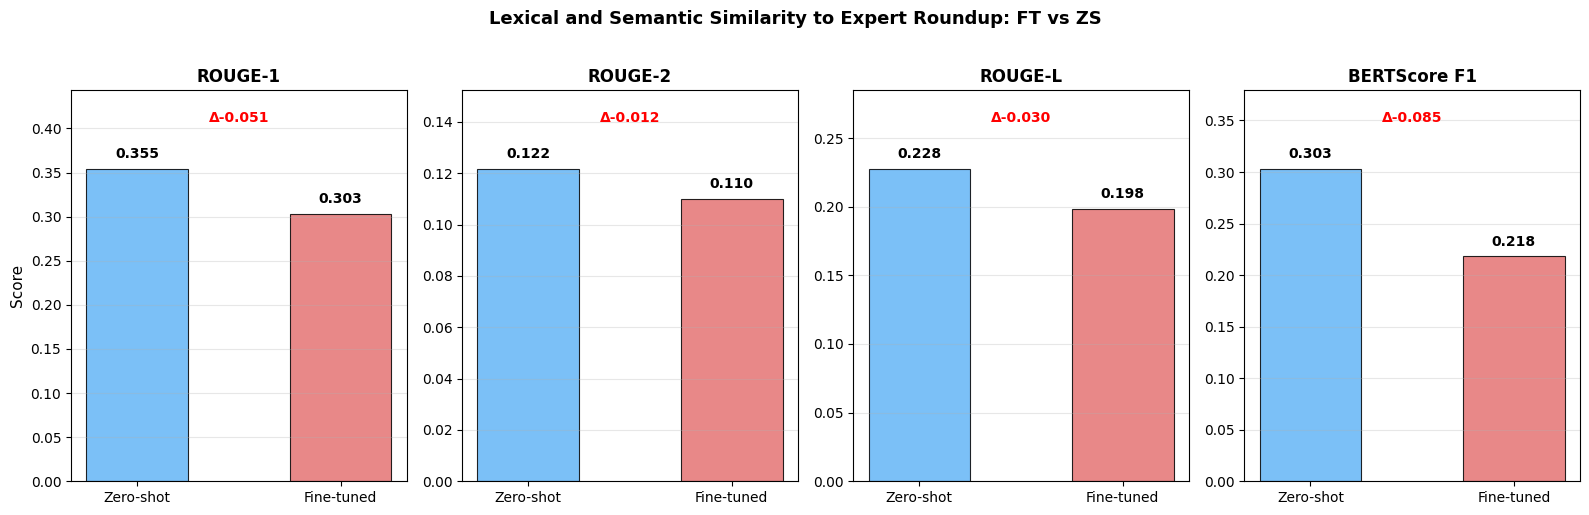

Saved: fig3_rouge_bertscore.png


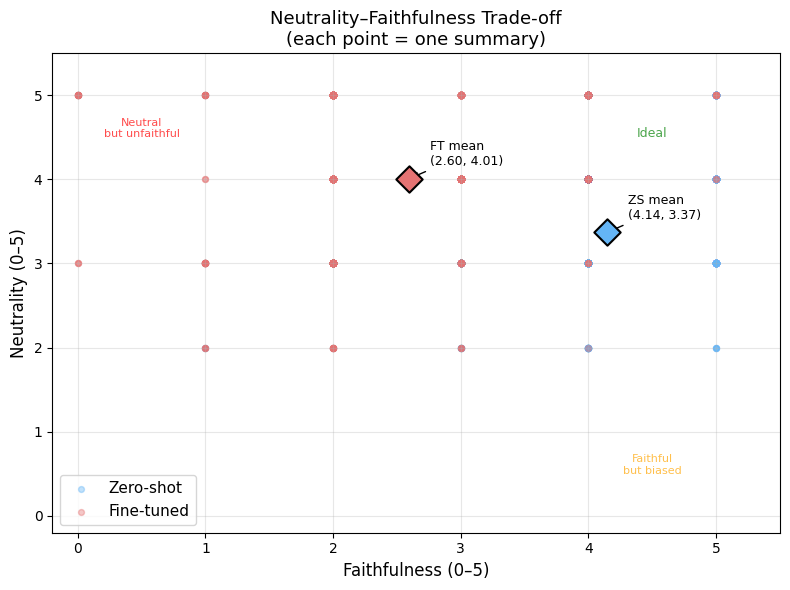

Saved: fig4_tradeoff_scatter.png


C:\Users\ImanGhotbi\AppData\Local\Temp\ipykernel_18704\3680114841.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([zs_spread, ft_spread], labels=["Zero-shot", "Fine-tuned"],


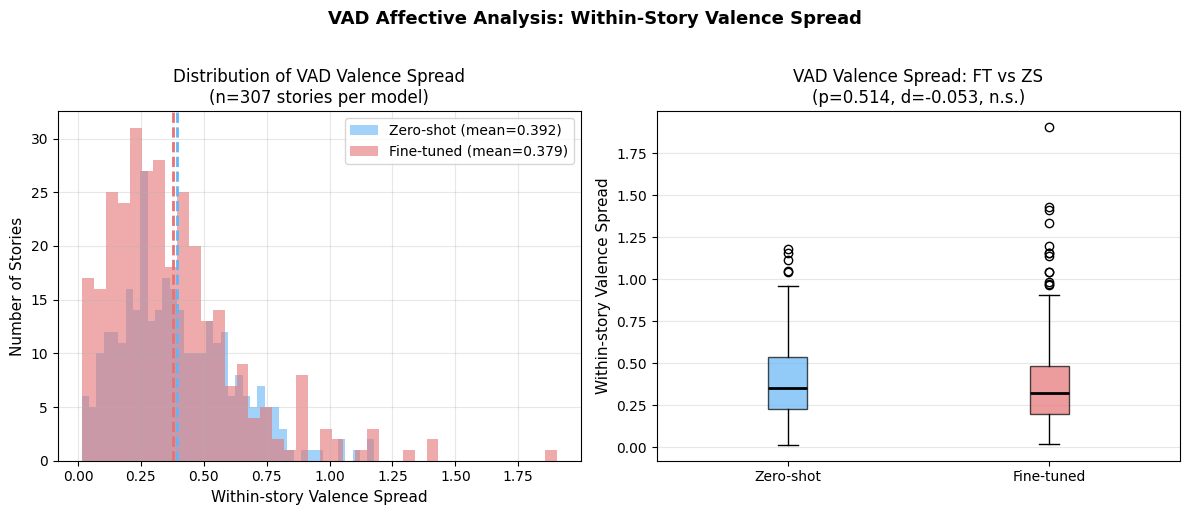

Saved: fig5_vad_spread.png

All figures saved to results/
Files: fig1_aggregate_judge_scores.png, fig2_stance_judge_scores.png,
       fig3_rouge_bertscore.png, fig4_tradeoff_scatter.png, fig5_vad_spread.png


In [38]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

FT_COLOR = "#E57373"   # red — fine-tuned
ZS_COLOR = "#64B5F6"   # blue — zero-shot
STANCE_COLORS = {"left": "#2196F3", "center": "#9E9E9E", "right": "#F44336"}

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1: Aggregate judge scores — FT vs ZS (goes in Section 4.1.1)
# This is the FIRST figure the reader sees — the main finding at a glance
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

judge_cols  = ["neutrality", "faithfulness", "roundup_alignment"]
judge_labels = ["Neutrality", "Faithfulness", "Roundup Alignment"]

agg_means = df.groupby("model")[judge_cols].mean()

for i, (col, label) in enumerate(zip(judge_cols, judge_labels)):
    zs_val = agg_means.loc["zeroshot", col]
    ft_val = agg_means.loc["finetuned", col]
    
    bars = axes[i].bar(["Zero-shot", "Fine-tuned"], [zs_val, ft_val],
                       color=[ZS_COLOR, FT_COLOR], alpha=0.85,
                       edgecolor="black", linewidth=0.8, width=0.5)
    axes[i].set_ylim(0, 5.5)
    axes[i].set_title(label, fontsize=13, fontweight="bold", pad=10)
    axes[i].set_ylabel("Mean Score (0–5)" if i == 0 else "", fontsize=11)
    axes[i].grid(True, alpha=0.3, axis="y")
    axes[i].tick_params(axis="x", labelsize=11)
    
    # Value labels on bars
    for bar, val in zip(bars, [zs_val, ft_val]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     val + 0.08, f"{val:.2f}",
                     ha="center", va="bottom", fontsize=11, fontweight="bold")
    
    # Arrow showing direction of change
    delta = ft_val - zs_val
    color = "green" if delta > 0 else "red"
    axes[i].annotate(f"Δ{delta:+.2f}",
                     xy=(0.5, 0.92), xycoords="axes fraction",
                     ha="center", fontsize=11, color=color, fontweight="bold")

plt.suptitle("LLM-as-Judge Scores: Fine-tuned vs Zero-shot (n=921)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("results/fig1_aggregate_judge_scores.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig1_aggregate_judge_scores.png")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2: Per-stance judge scores — grouped bar (goes in Section 4.1.2–4.1.4)
# Shows whether the effect is uniform across stances or stance-dependent
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

stance_order = ["left", "center", "right"]
x = np.arange(len(stance_order))
width = 0.35

stance_means = df.groupby(["model", "stance"])[judge_cols].mean()

for i, (col, label) in enumerate(zip(judge_cols, judge_labels)):
    zs_vals = [stance_means.loc[("zeroshot", s), col] for s in stance_order]
    ft_vals = [stance_means.loc[("finetuned", s), col] for s in stance_order]
    
    axes[i].bar(x - width/2, zs_vals, width, label="Zero-shot",
                color=ZS_COLOR, alpha=0.85, edgecolor="black", linewidth=0.8)
    axes[i].bar(x + width/2, ft_vals, width, label="Fine-tuned",
                color=FT_COLOR, alpha=0.85, edgecolor="black", linewidth=0.8)
    
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(["Left", "Center", "Right"], fontsize=11)
    axes[i].set_ylim(0, 5.5)
    axes[i].set_title(label, fontsize=13, fontweight="bold")
    axes[i].set_ylabel("Mean Score (0–5)" if i == 0 else "", fontsize=11)
    axes[i].legend(fontsize=10) if i == 0 else None
    axes[i].grid(True, alpha=0.3, axis="y")

plt.suptitle("Judge Scores by Stance: Fine-tuned vs Zero-shot",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("results/fig2_stance_judge_scores.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig2_stance_judge_scores.png")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3: ROUGE + BERTScore aggregate (goes in Section 4.2.1)
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

lex_cols   = ["rouge1_f", "rouge2_f", "rougeL_f", "bertscore_f1"]
lex_labels = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore F1"]

agg_lex = df.groupby("model")[lex_cols].mean()

for i, (col, label) in enumerate(zip(lex_cols, lex_labels)):
    zs_val = agg_lex.loc["zeroshot", col]
    ft_val = agg_lex.loc["finetuned", col]
    
    bars = axes[i].bar(["Zero-shot", "Fine-tuned"], [zs_val, ft_val],
                       color=[ZS_COLOR, FT_COLOR], alpha=0.85,
                       edgecolor="black", linewidth=0.8, width=0.5)
    
    ymax = max(zs_val, ft_val) * 1.25
    axes[i].set_ylim(0, ymax)
    axes[i].set_title(label, fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Score" if i == 0 else "", fontsize=11)
    axes[i].grid(True, alpha=0.3, axis="y")
    
    for bar, val in zip(bars, [zs_val, ft_val]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     val + ymax*0.02, f"{val:.3f}",
                     ha="center", va="bottom", fontsize=10, fontweight="bold")
    
    delta = ft_val - zs_val
    axes[i].annotate(f"Δ{delta:+.3f}",
                     xy=(0.5, 0.92), xycoords="axes fraction",
                     ha="center", fontsize=10,
                     color="green" if delta > 0 else "red", fontweight="bold")

plt.suptitle("Lexical and Semantic Similarity to Expert Roundup: FT vs ZS",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("results/fig3_rouge_bertscore.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig3_rouge_bertscore.png")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 4: Trade-off scatter — neutrality vs faithfulness per example
# (goes in Section 4.5 Summary, or the Discussion)
# Best single figure to show the trade-off is not accidental
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))

for model, color, label, alpha in [
    ("zeroshot", ZS_COLOR, "Zero-shot", 0.4),
    ("finetuned", FT_COLOR, "Fine-tuned", 0.4)
]:
    subset = df[df["model"] == model]
    ax.scatter(subset["faithfulness"], subset["neutrality"],
               color=color, alpha=alpha, s=18, label=label)

# Add mean crosshairs
for model, color, marker in [("zeroshot", ZS_COLOR, "D"), ("finetuned", FT_COLOR, "D")]:
    subset = df[df["model"] == model]
    ax.scatter(subset["faithfulness"].mean(), subset["neutrality"].mean(),
               color=color, s=180, marker=marker, edgecolors="black",
               linewidth=1.5, zorder=5)
    ax.annotate(f"{'FT' if model == 'finetuned' else 'ZS'} mean\n"
                f"({subset['faithfulness'].mean():.2f}, {subset['neutrality'].mean():.2f})",
                xy=(subset["faithfulness"].mean(), subset["neutrality"].mean()),
                xytext=(15, 10), textcoords="offset points", fontsize=9,
                arrowprops=dict(arrowstyle="->", color="black", lw=1))

ax.set_xlabel("Faithfulness (0–5)", fontsize=12)
ax.set_ylabel("Neutrality (0–5)", fontsize=12)
ax.set_title("Neutrality–Faithfulness Trade-off\n(each point = one summary)", fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(-0.2, 5.5)
ax.set_ylim(-0.2, 5.5)
ax.grid(True, alpha=0.3)

# Quadrant annotations
ax.text(4.5, 4.5, "Ideal", fontsize=9, color="green", ha="center", alpha=0.7)
ax.text(0.5, 4.5, "Neutral\nbut unfaithful", fontsize=8, color="red", ha="center", alpha=0.7)
ax.text(4.5, 0.5, "Faithful\nbut biased", fontsize=8, color="orange", ha="center", alpha=0.7)

plt.tight_layout()
plt.savefig("results/fig4_tradeoff_scatter.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig4_tradeoff_scatter.png")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 5: VAD valence spread distribution (goes in Section 4.3.2)
# ═══════════════════════════════════════════════════════════════════════════════


vad_spread = (
    df.groupby(["model", "example_id"])["valence"]
    .agg(lambda x: x.max() - x.min())
    .reset_index()
    .rename(columns={"valence": "valence_spread"})
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Replace hardcoded values with computed ones
ft_spread = vad_spread[vad_spread["model"] == "finetuned"]["valence_spread"]
zs_spread = vad_spread[vad_spread["model"] == "zeroshot"]["valence_spread"]
t_vad, p_vad = stats.ttest_ind(ft_spread, zs_spread)
d_vad = (ft_spread.mean() - zs_spread.mean()) / np.sqrt(
    (ft_spread.std()**2 + zs_spread.std()**2) / 2
)

# Histogram
axes[0].hist(zs_spread, bins=40, alpha=0.6, color=ZS_COLOR, label=f"Zero-shot (mean={zs_spread.mean():.3f})")
axes[0].hist(ft_spread, bins=40, alpha=0.6, color=FT_COLOR, label=f"Fine-tuned (mean={ft_spread.mean():.3f})")
axes[0].axvline(zs_spread.mean(), color=ZS_COLOR, linestyle="--", linewidth=2)
axes[0].axvline(ft_spread.mean(), color=FT_COLOR, linestyle="--", linewidth=2)
axes[0].set_xlabel("Within-story Valence Spread", fontsize=11)
axes[0].set_ylabel("Number of Stories", fontsize=11)
axes[0].set_title("Distribution of VAD Valence Spread\n(n=307 stories per model)", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Box plot
bp = axes[1].boxplot([zs_spread, ft_spread], labels=["Zero-shot", "Fine-tuned"],
                     patch_artist=True, notch=False,
                     medianprops=dict(color="black", linewidth=2))
bp["boxes"][0].set_facecolor(ZS_COLOR)
bp["boxes"][1].set_facecolor(FT_COLOR)
for patch in bp["boxes"]:
    patch.set_alpha(0.7)

axes[1].set_ylabel("Within-story Valence Spread", fontsize=11)
axes[1].set_title(f"VAD Valence Spread: FT vs ZS\n(p={p_vad:.3f}, d={d_vad:.3f}, n.s.)", fontsize=12)
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("VAD Affective Analysis: Within-Story Valence Spread",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("results/fig5_vad_spread.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig5_vad_spread.png")

print("\nAll figures saved to results/")
print("Files: fig1_aggregate_judge_scores.png, fig2_stance_judge_scores.png,")
print("       fig3_rouge_bertscore.png, fig4_tradeoff_scatter.png, fig5_vad_spread.png")

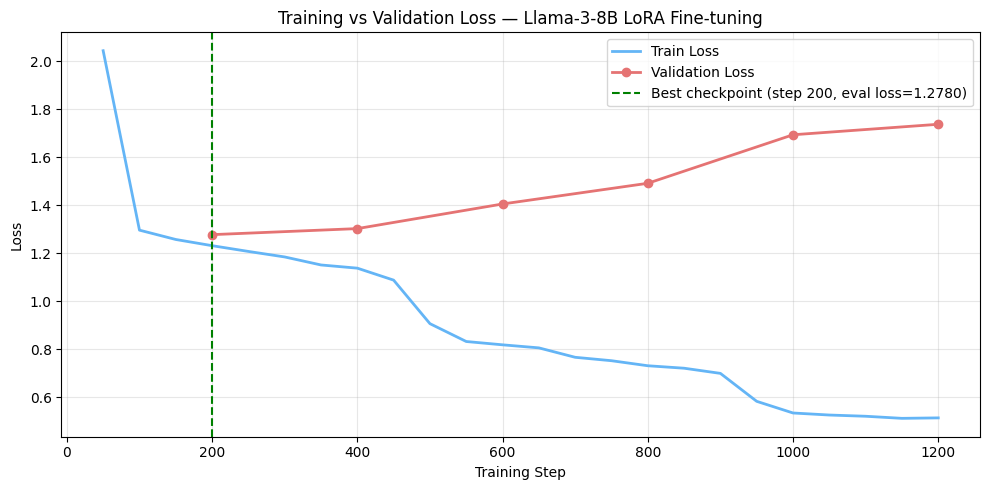

Best checkpoint: ./llama3-bias-lora-v5/checkpoint-200
Best eval loss:  1.2780 at step 200 (epoch 0.44)
Final eval loss: 1.7379 at step 1200
Overfitting gap: 0.4599


In [33]:
import json
import matplotlib.pyplot as plt
import os

# Look for trainer_state in results/ first, then current directory
for candidate in ["results/trainer_state.json", "trainer_state.json"]:
    if os.path.exists(candidate):
        state_path = candidate
        break

with open(state_path) as f:
    state = json.load(f)

train_steps, train_loss, eval_steps, eval_loss = [], [], [], []
for entry in state["log_history"]:
    if "loss" in entry:
        train_steps.append(entry["step"])
        train_loss.append(entry["loss"])
    if "eval_loss" in entry:
        eval_steps.append(entry["step"])
        eval_loss.append(entry["eval_loss"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_steps, train_loss, label="Train Loss", color="#64B5F6", linewidth=2)
ax.plot(eval_steps, eval_loss, label="Validation Loss", color="#E57373",
        linewidth=2, marker="o")
ax.axvline(x=200, color="green", linestyle="--", linewidth=1.5,
           label=f"Best checkpoint (step 200, eval loss={state['best_metric']:.4f})")
ax.set_xlabel("Training Step")
ax.set_ylabel("Loss")
ax.set_title("Training vs Validation Loss — Llama-3-8B LoRA Fine-tuning")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/training_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Best checkpoint: {state['best_model_checkpoint']}")
print(f"Best eval loss:  {state['best_metric']:.4f} at step 200 (epoch 0.44)")
print(f"Final eval loss: {eval_loss[-1]:.4f} at step {eval_steps[-1]}")
print(f"Overfitting gap: {eval_loss[-1] - state['best_metric']:.4f}")

In [34]:
from scipy import stats
import numpy as np

# ── Ensure numeric types ──────────────────────────────────────────────────────
for col in ["neutrality", "faithfulness", "roundup_alignment",
            "rouge1_f", "rouge2_f", "rougeL_f", "bertscore_f1",
            "valence", "arousal", "dominance"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ── 1. AGGREGATE: model-level means (collapsed across all stances) ────────────
print("=" * 65)
print("TABLE A: AGGREGATE RESULTS — FT vs ZS (collapsed across stances)")
print("=" * 65)

agg = df.groupby("model")[
    ["neutrality", "faithfulness", "roundup_alignment",
     "rouge1_f", "rouge2_f", "rougeL_f", "bertscore_f1",
     "valence", "arousal", "dominance"]
].mean().round(4)
print(agg.T)

# ── 2. Statistical tests: paired by (example_id, stance) ─────────────────────
print("\n" + "=" * 65)
print("TABLE B: STATISTICAL TESTS — FT vs ZS (paired t-test)")
print("=" * 65)
print(f"{'Metric':<25} {'ZS mean':>9} {'FT mean':>9} {'t':>8} {'p':>8} {'d':>8} {'Sig?':>6}")
print("-" * 75)

judge_metrics = ["neutrality", "faithfulness", "roundup_alignment"]
lex_metrics   = ["rouge1_f", "rouge2_f", "rougeL_f", "bertscore_f1"]

for col in judge_metrics + lex_metrics:
    ft = df[df["model"] == "finetuned"].sort_values(["example_id", "stance"])[col].reset_index(drop=True)
    zs = df[df["model"] == "zeroshot"].sort_values(["example_id", "stance"])[col].reset_index(drop=True)
    
    # Drop NaN pairs
    mask = ft.notna() & zs.notna()
    ft_clean, zs_clean = ft[mask], zs[mask]
    
    t, p = stats.ttest_rel(ft_clean, zs_clean)
    d = (ft_clean.mean() - zs_clean.mean()) / np.sqrt(
        (ft_clean.std()**2 + zs_clean.std()**2) / 2
    )
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
    print(f"{col:<25} {zs_clean.mean():>9.4f} {ft_clean.mean():>9.4f} {t:>8.3f} {p:>8.4f} {d:>8.4f} {sig:>6}")

# ── 3. PER-STANCE breakdown ───────────────────────────────────────────────────
print("\n" + "=" * 65)
print("TABLE C: PER-STANCE BREAKDOWN — FT vs ZS")
print("=" * 65)

stance_agg = df.groupby(["model", "stance"])[
    ["neutrality", "faithfulness", "roundup_alignment",
     "rouge1_f", "rouge2_f", "rougeL_f", "bertscore_f1"]
].mean().round(4)
print(stance_agg)

# ── 4. VAD spread ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("TABLE D: VAD WITHIN-STORY VALENCE SPREAD")
print("=" * 65)

vad_spread = (
    df.groupby(["model", "example_id"])["valence"]
    .agg(lambda x: x.max() - x.min())
    .reset_index()
    .rename(columns={"valence": "valence_spread"})
)
print(vad_spread.groupby("model")["valence_spread"].describe().round(4))

ft_spread = vad_spread[vad_spread["model"] == "finetuned"]["valence_spread"]
zs_spread = vad_spread[vad_spread["model"] == "zeroshot"]["valence_spread"]
t, p = stats.ttest_ind(ft_spread, zs_spread)
d = (ft_spread.mean() - zs_spread.mean()) / np.sqrt(
    (ft_spread.std()**2 + zs_spread.std()**2) / 2
)
print(f"\nVAD spread t-test: t={t:.3f}, p={p:.4f}, Cohen's d={d:.4f}")
print(f"FT mean: {ft_spread.mean():.4f}, ZS mean: {zs_spread.mean():.4f}")

TABLE A: AGGREGATE RESULTS — FT vs ZS (collapsed across stances)
model              finetuned  zeroshot
neutrality            4.0087    3.3692
faithfulness          2.5972    4.1444
roundup_alignment     2.3920    3.1346
rouge1_f              0.3033    0.3545
rouge2_f              0.1099    0.1218
rougeL_f              0.1982    0.2278
bertscore_f1          0.2182    0.3034
valence               5.2919    5.2973
arousal               4.0611    4.1041
dominance             5.4140    5.4089

TABLE B: STATISTICAL TESTS — FT vs ZS (paired t-test)
Metric                      ZS mean   FT mean        t        p        d   Sig?
---------------------------------------------------------------------------
neutrality                   3.3692    4.0087   20.212   0.0000   0.8095    ***
faithfulness                 4.1444    2.5972  -46.106   0.0000  -1.9392    ***
roundup_alignment            3.1346    2.3920  -26.814   0.0000  -0.9391    ***
rouge1_f                     0.3545    0.3033  -18.061 

In [35]:
# Use text columns only if they exist in df (not available if loaded from clean CSV)
TEXT_COLS = ["input_article", "generated_summary", "roundup_text"]
available_text = [c for c in TEXT_COLS if c in df.columns]

if not available_text:
    print("WARNING: Text columns not in df — loading from source files for error analysis")
    import csv
    def load_messy_csv(filepath):
        rows = []
        with open(filepath, encoding="utf-8", newline='') as f:
            reader = csv.reader(f, quotechar='"', skipinitialspace=True)
            headers = next(reader)
            for row in reader:
                if len(row) == len(headers):
                    rows.append(row)
                elif len(row) > len(headers):
                    fixed = row[:len(headers)-1] + [','.join(row[len(headers)-1:])]
                    rows.append(fixed)
        return pd.DataFrame(rows, columns=headers)

    ft_raw = load_messy_csv("finetuned_clean_judged.csv")
    zs_raw = load_messy_csv("zeroshot_clean_judged.csv")
    ft_raw["model"] = "finetuned"
    zs_raw["model"] = "zeroshot"
    df_full = pd.concat([ft_raw, zs_raw], ignore_index=True)
    # Merge text columns back onto df by example_id + stance + model
    df_full["example_id"] = pd.to_numeric(df_full["example_id"], errors="coerce")
    df["example_id"] = pd.to_numeric(df["example_id"], errors="coerce")
    df_with_text = df.merge(
        df_full[["example_id", "stance", "model"] + TEXT_COLS],
        on=["example_id", "stance", "model"], how="left"
    )
else:
    df_with_text = df

EXPORT_COLS = ["example_id", "topic", "stance", "model"] + \
              available_text + \
              ["neutrality", "faithfulness", "roundup_alignment", "reasoning"]
EXPORT_COLS = [c for c in EXPORT_COLS if c in df_with_text.columns]

df_with_text["faithfulness"]      = pd.to_numeric(df_with_text["faithfulness"], errors="coerce")
df_with_text["neutrality"]        = pd.to_numeric(df_with_text["neutrality"], errors="coerce")
df_with_text["roundup_alignment"] = pd.to_numeric(df_with_text["roundup_alignment"], errors="coerce")

low_faith_ft = df_with_text[
    (df_with_text["model"] == "finetuned") &
    (df_with_text["faithfulness"] <= 2)
][EXPORT_COLS].sort_values("faithfulness")
low_faith_ft.to_csv("error_analysis_low_faithfulness.csv", index=False)
print(f"Low faithfulness FT examples: {len(low_faith_ft)}")

tradeoff = df_with_text[
    (df_with_text["model"] == "finetuned") &
    (df_with_text["neutrality"] >= 4) &
    (df_with_text["faithfulness"] <= 2)
][EXPORT_COLS].sort_values("neutrality", ascending=False)
tradeoff.to_csv("error_analysis_tradeoff.csv", index=False)
print(f"High neutrality + low faithfulness FT examples: {len(tradeoff)}")

worst_stories = (
    df_with_text[df_with_text["model"] == "finetuned"]
    .groupby("example_id")["faithfulness"]
    .mean()
    .sort_values()
    .head(15)
    .index
)
comparison = df_with_text[df_with_text["example_id"].isin(worst_stories)].sort_values(
    ["example_id", "stance", "model"]
)[EXPORT_COLS]
comparison.to_csv("error_analysis_comparison.csv", index=False)
print(f"Side-by-side comparison: {len(comparison)} rows ({len(worst_stories)} stories)")

high_faith_zs = df_with_text[
    (df_with_text["model"] == "zeroshot") &
    (df_with_text["faithfulness"] >= 4)
][EXPORT_COLS].sort_values("faithfulness", ascending=False).head(20)
high_faith_zs.to_csv("error_analysis_zeroshot_faithful.csv", index=False)
print(f"High faithfulness ZS contrast set: {len(high_faith_zs)}")

Low faithfulness FT examples: 477
High neutrality + low faithfulness FT examples: 253
Side-by-side comparison: 90 rows (15 stories)
High faithfulness ZS contrast set: 20


In [36]:
import os
import shutil

os.makedirs("results", exist_ok=True)

# ── Aggregated results summary — safe to publish, no article text ─────────────
summary = df.groupby(["model", "stance"])[
    ["neutrality", "coverage", "faithfulness", "roundup_alignment",
     "rouge1_f", "rouge2_f", "rougeL_f", "bertscore_f1",
     "valence", "arousal", "dominance", "vad_coverage"]
].mean().round(4)
summary.to_csv("results/results_summary.csv")
print("Saved: results/results_summary.csv")

# ── Copy any charts saved to root directory (legacy filenames) ────────────────
legacy_charts = [
    "training_curve.png",
    "judge_comparison.png", 
    "rouge_comparison.png",
    "trainer_state.json"
]
for fname in legacy_charts:
    if os.path.exists(fname) and not os.path.exists(f"results/{fname}"):
        shutil.copy(fname, f"results/{fname}")
        print(f"Copied: {fname} → results/")

# ── Verify results/ folder ────────────────────────────────────────────────────
print(f"\nresults/ folder contents ({len(os.listdir('results'))} files):")
for f in sorted(os.listdir("results")):
    size_kb = os.path.getsize(f"results/{f}") / 1024
    print(f"  {f:<45} {size_kb:>6.1f} KB")

# ── Final sanity check on summary ────────────────────────────────────────────
print(f"\nResults summary shape: {summary.shape}")
print(summary.to_string())

Saved: results/results_summary.csv

results/ folder contents (19 files):
  allsides_processed_with_splits.csv            6816.1 KB
  allsides_processed_with_splits.pkl            6542.5 KB
  article_similarity_distribution.png            188.9 KB
  fig1_aggregate_judge_scores.png                110.4 KB
  fig2_stance_judge_scores.png                   107.6 KB
  fig3_rouge_bertscore.png                       160.0 KB
  fig4_tradeoff_scatter.png                      124.6 KB
  fig5_vad_spread.png                            197.2 KB
  judge_comparison.png                           120.1 KB
  length_analysis.png                            348.3 KB
  per_story_similarity.png                       221.3 KB
  results_summary.csv                              0.7 KB
  rouge_comparison.png                           113.6 KB
  roundup_stance_alignment.png                   159.0 KB
  split_analysis.png                             191.8 KB
  trainer_state.json                               5.9 KB